## Load the dataset using pandas 

In [1]:
# Installing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("diabetes.csv")
df

FileNotFoundError: [Errno 2] No such file or directory: 'diabetes.csv'

## Check shape of dataset 

In [27]:
df.shape

(768, 9)

## Displaying data types of all columns 

In [28]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

## Displaying summary statistics

In [29]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# PART 2: EXPLORATORY DATA ANALYSIS (EDA)

In [30]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## Create histograms for all numerical features 

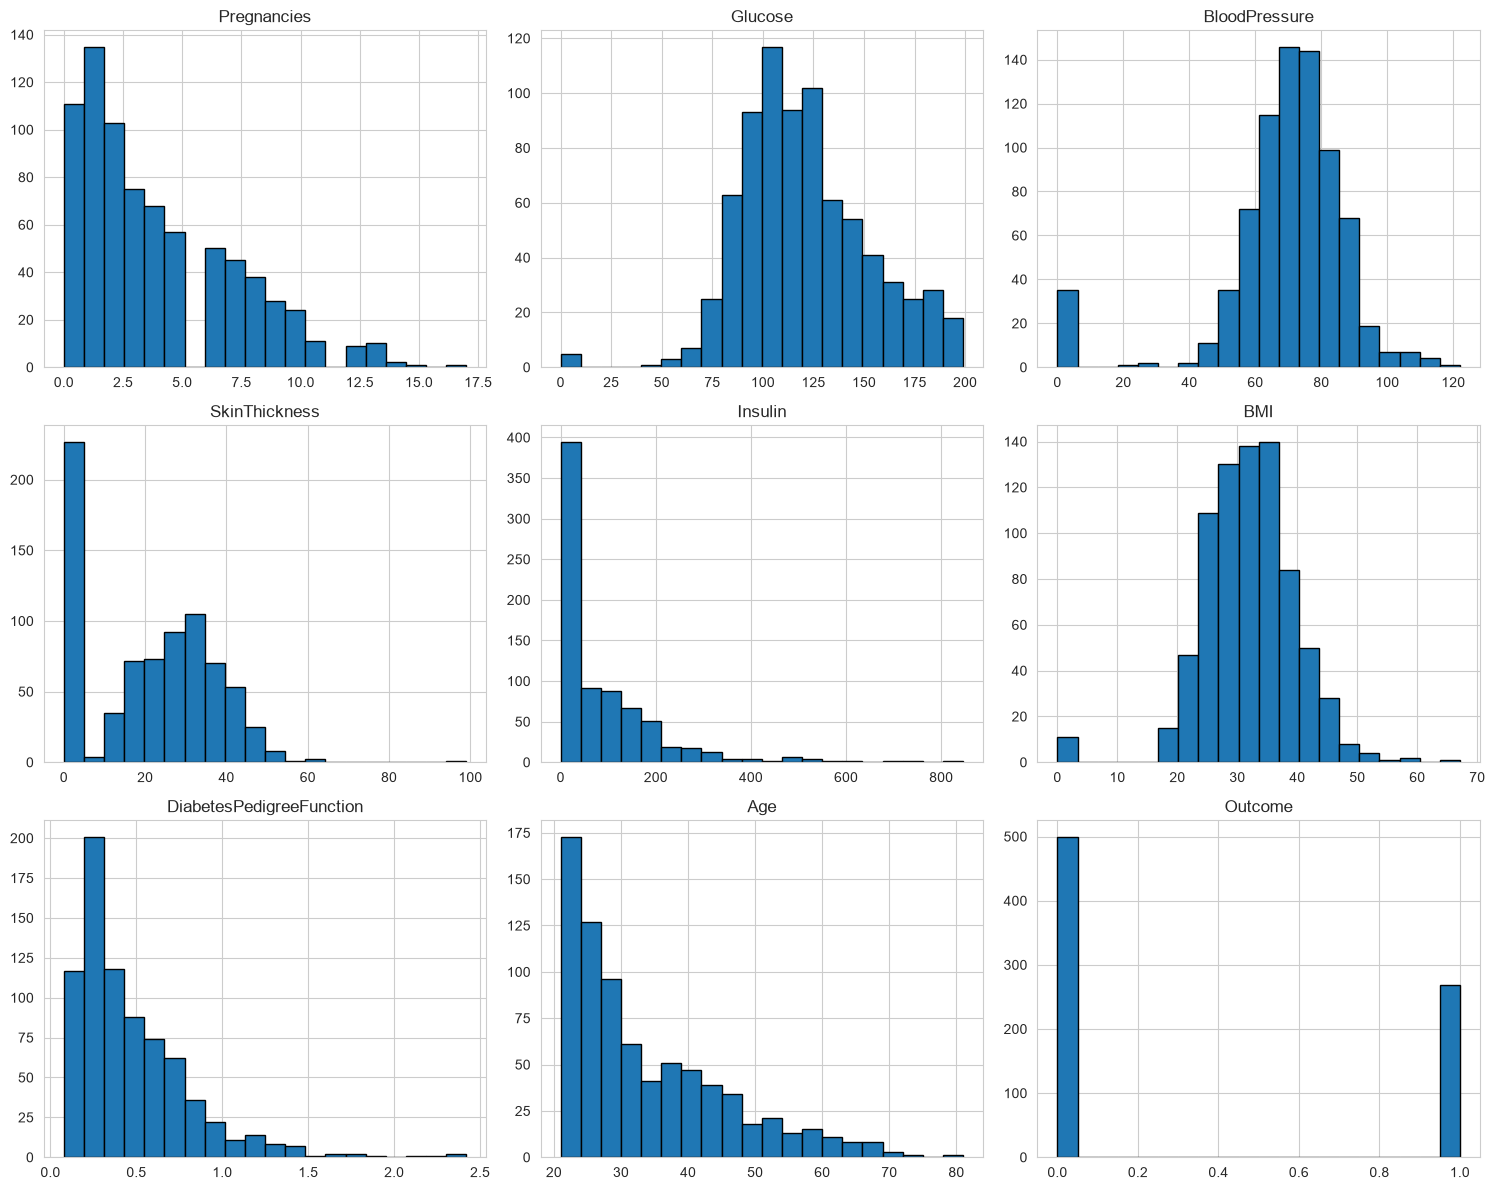

In [31]:
df.hist(figsize=(15, 12), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()

## Create boxplots to identify outliers in numerical features

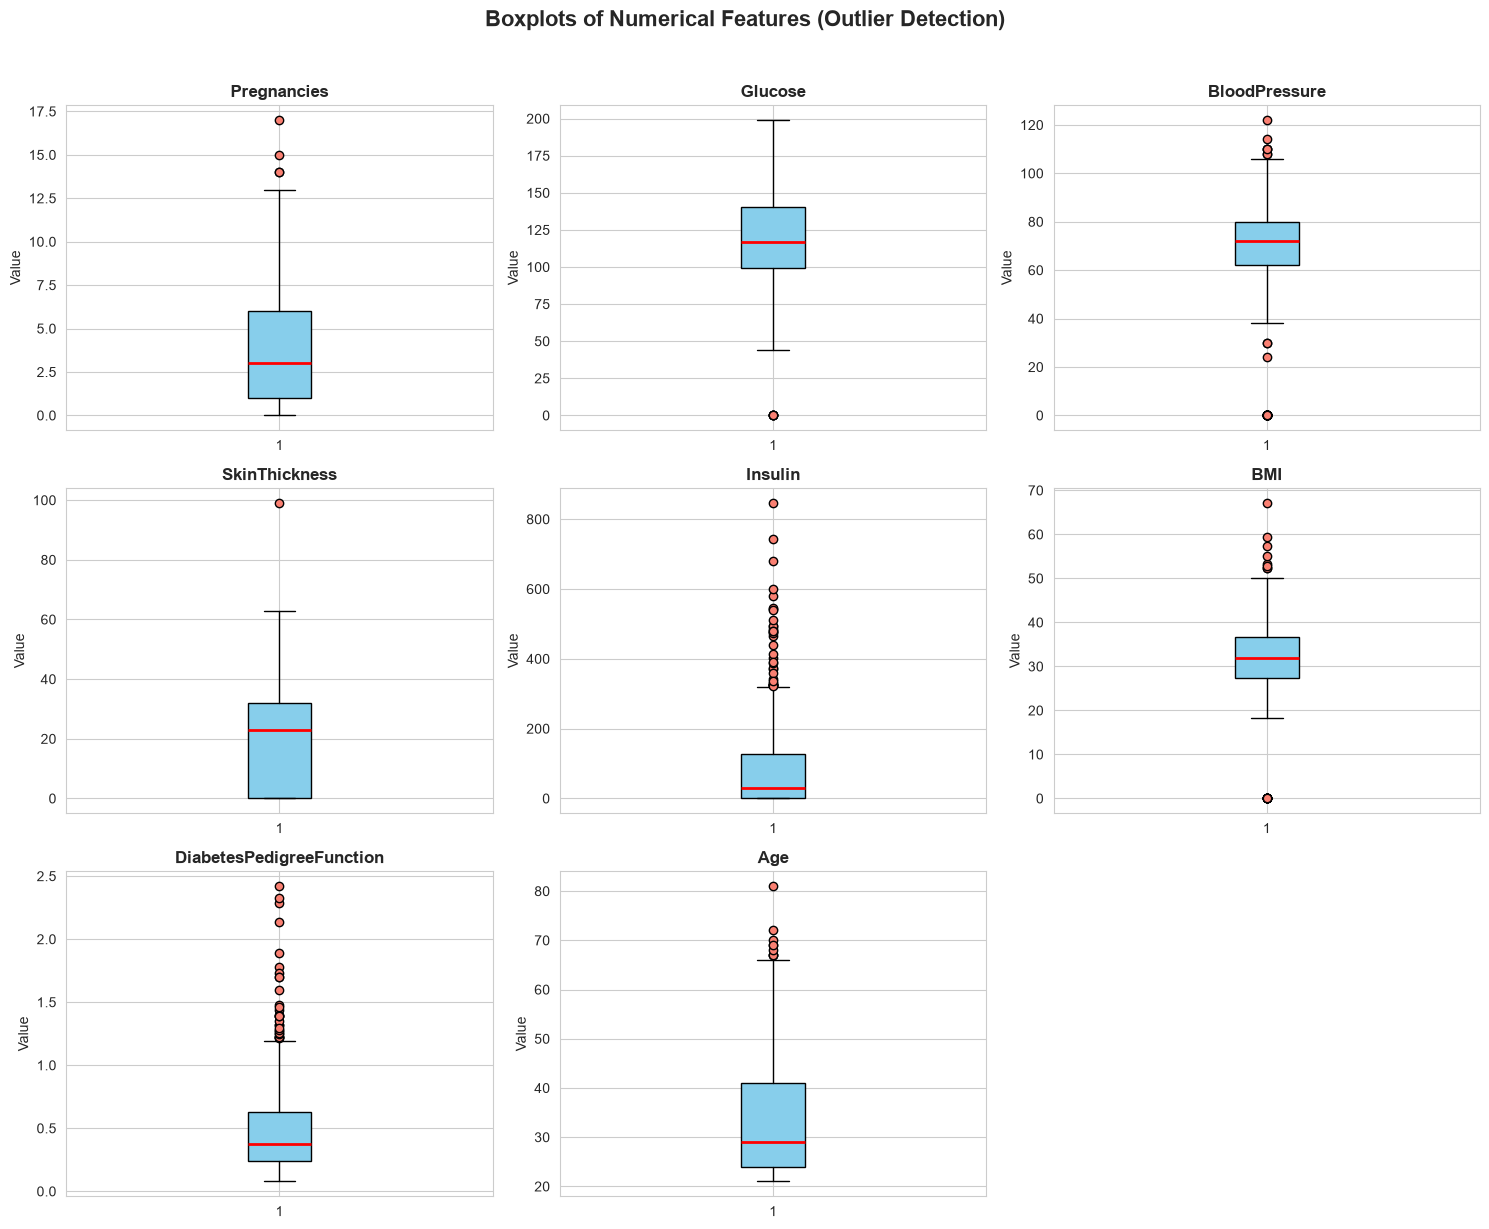

In [32]:
features = df.columns[:-1]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(features):
    axes[idx].boxplot(df[feature], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='skyblue', color='black'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', markerfacecolor='salmon', markersize=6, markeredgecolor='black'))
    axes[idx].set_title(feature, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Value')

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots of Numerical Features (Outlier Detection)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Generate correlation heatmap to find feature correlations with target variable

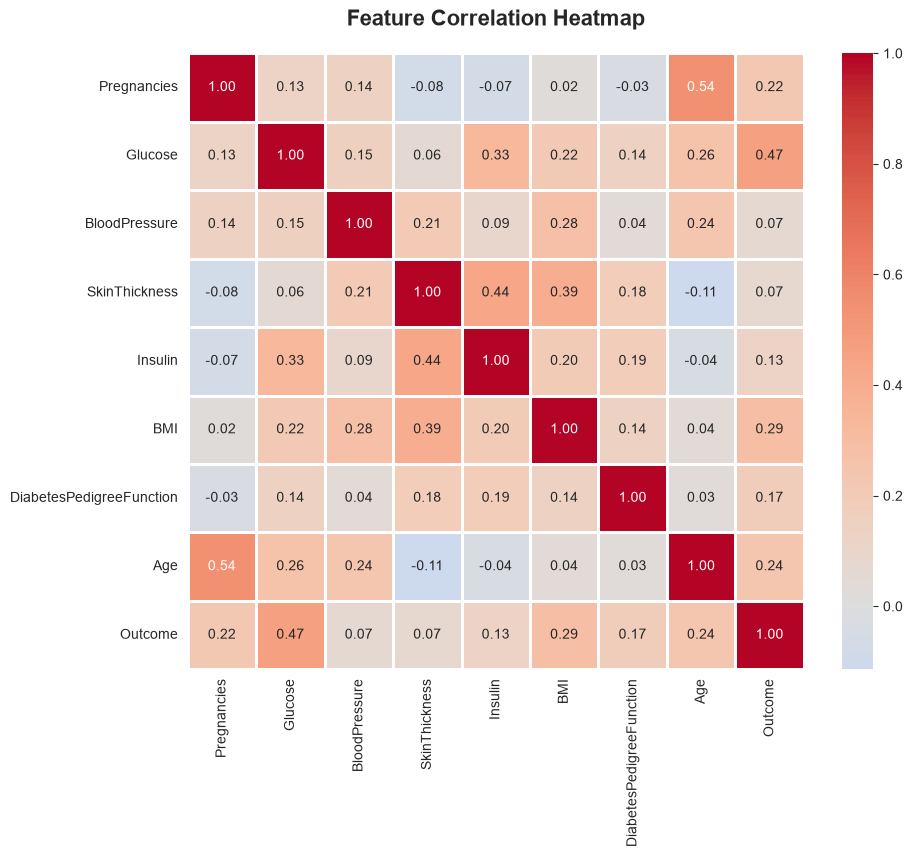

In [33]:
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1, fmt=".2f")
plt.title("Feature Correlation Heatmap", fontsize=16, pad=20, fontweight='bold')
plt.show()

## Create pairplots for top features colored by Outcome

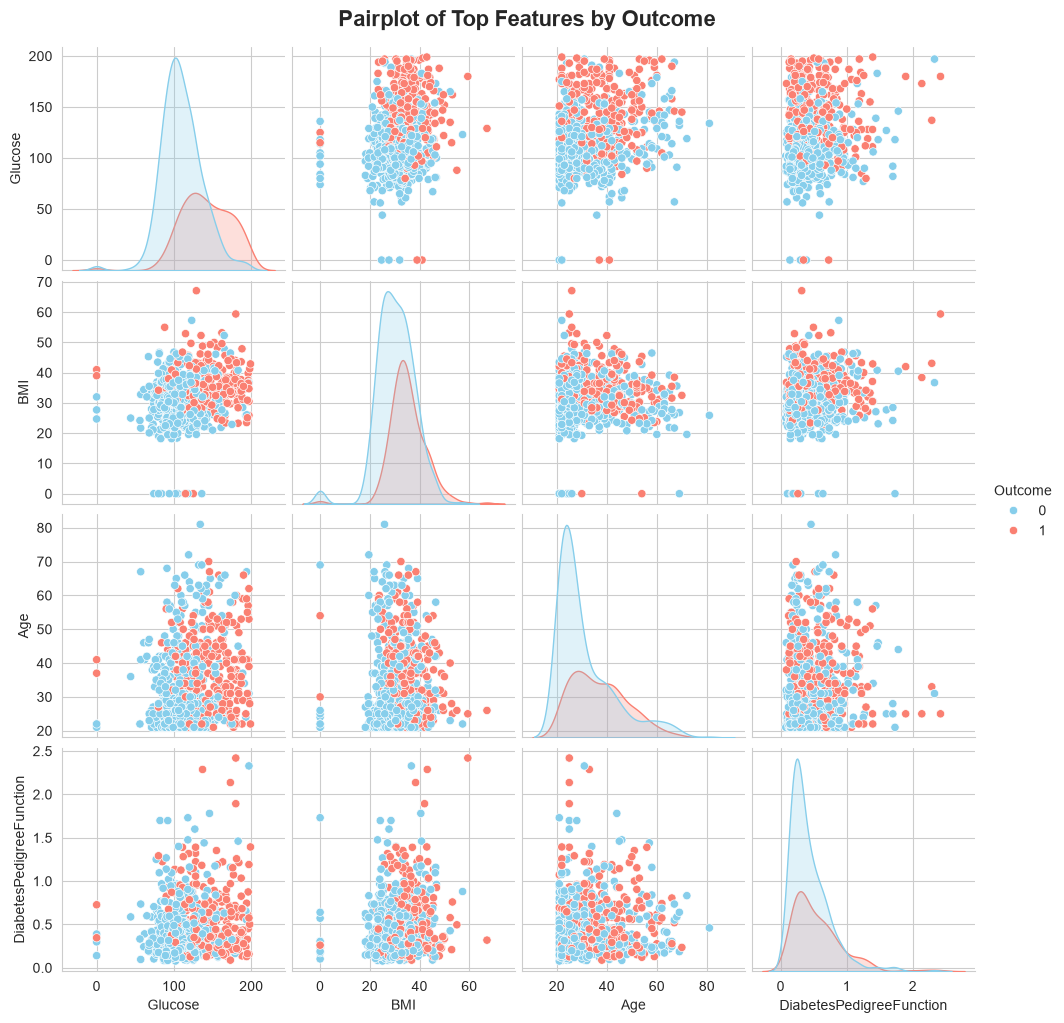

In [34]:
top_features = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Outcome']

sns.pairplot(df[top_features], hue='Outcome', palette={0: 'skyblue', 1: 'salmon'}, diag_kind='kde')
plt.suptitle('Pairplot of Top Features by Outcome', y=1.02, fontsize=16, fontweight='bold')
plt.show()

## Identify zero values in Glucose, BloodPressure, SkinThickness, Insulin, BMI (treat as missing)

In [35]:
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = (df[cols_with_zeros] == 0).sum()
print("Zero value counts (treated as missing):")
print(zero_counts)

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
print("\nMissing values after replacement:")
print(df[cols_with_zeros].isnull().sum())

Zero value counts (treated as missing):
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Missing values after replacement:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## Visualize feature distributions stratified by diabetes outcome (diabetic vs non-diabetic)

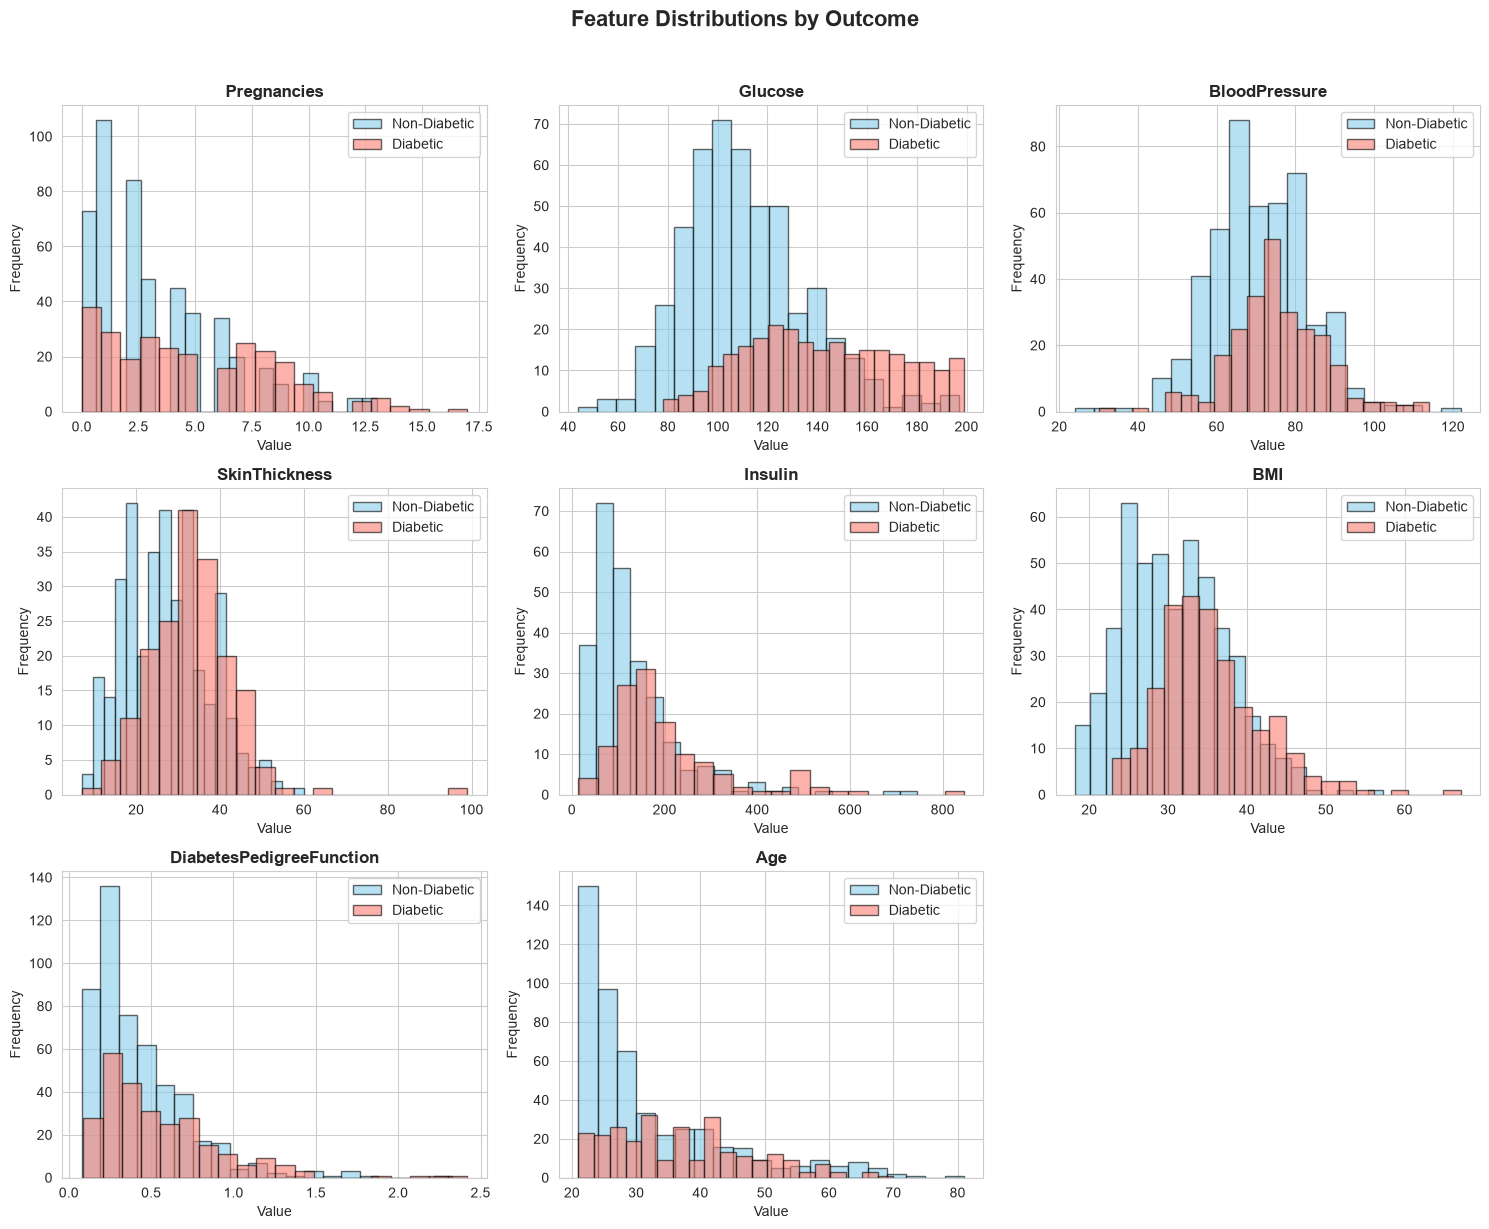

In [36]:
features = df.columns[:-1]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(features):
    for outcome in [0, 1]:
        data = df[df["Outcome"] == outcome][feature]
        label = "Diabetic" if outcome == 1 else "Non-Diabetic"
        color = "salmon" if outcome == 1 else "skyblue"
        axes[idx].hist(data, bins=20, alpha=0.6, label=label, color=color, edgecolor='black')
    axes[idx].set_title(feature, fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Feature Distributions by Outcome', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Write a summary of EDA findings 

Exploratory analysis of the diabetes dataset revealed a class imbalance, with non-diabetic cases outnumbering diabetic cases, which should be considered when evaluating model performance. The correlation heatmap showed that Glucose had the strongest positive relationship with the Outcome variable, followed by BMI and Age, suggesting these features are likely to be strong predictors of diabetes risk. Distribution plots comparing diabetic vs. non-diabetic groups showed noticeably higher median values for Glucose, BMI, and Age among diabetic patients, while features like BloodPressure and SkinThickness showed more overlap between the two groups. The boxplot analysis further identified several outliers, particularly in Insulin, SkinThickness, and DiabetesPedigreeFunction, along with biologically implausible zero values in Glucose, BloodPressure, and BMI, indicating these are likely missing values encoded as zeros rather than true measurements. Overall, these findings suggest a need for careful handling of zero/missing values and outliers before model training, while confirming that Glucose, BMI, and Age are the most informative features for predicting diabetes.

## PART 3: DATA PREPROCESSING

## Handle zero values in Glucose by replacing with column median

In [37]:
df['Glucose'] = df['Glucose'].replace(0, df['Glucose'].median())

## Handle zero values in BloodPressure by replacing with column median

In [38]:
df['BloodPressure'] = df['BloodPressure'].replace(0, df['BloodPressure'].median())

## Handle zero values in SkinThickness,, Insulin and BMI by replacing with column median

In [39]:
df['SkinThickness'] = df['SkinThickness'].replace(0, df['SkinThickness'].median())
df['Insulin'] = df['Insulin'].replace(0, df['Insulin'].median())
df['BMI'] = df['BMI'].replace(0, df['BMI'].median())

## Check for and remove duplicate records (if any)	

In [40]:
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (768, 9)


In [44]:
df.fillna(df.median(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


## Handle class imbalance using SMOTE (Synthetic Minority Over-sampling Technique)

In [45]:
from imblearn.over_sampling import SMOTE

X = df.drop(columns="Outcome")
y = df["Outcome"]

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Class distribution before SMOTE:")
print(y.value_counts())
print("\nClass distribution after SMOTE:")
print(y_resampled.value_counts())

Class distribution before SMOTE:
Outcome
0    500
1    268
Name: count, dtype: int64

Class distribution after SMOTE:
Outcome
1    500
0    500
Name: count, dtype: int64


## Scale numerical features using StandardScaler

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

## Scale numerical features using MinMaxScaler and compare with StandardScaler

In [47]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

standard_scaler = StandardScaler()
X_standard_scaled = standard_scaler.fit_transform(X_resampled)

minmax_scaler = MinMaxScaler()
X_minmax_scaled = minmax_scaler.fit_transform(X_resampled)

print("StandardScaler output (first 5 rows):")
print(X_standard_scaled[:5])

print("\nMinMaxScaler output (first 5 rows):")
print(X_minmax_scaled[:5])

print("\nStandardScaler - Mean:", X_standard_scaled.mean(axis=0).round(2))
print("StandardScaler - Std:", X_standard_scaled.std(axis=0).round(2))

print("\nMinMaxScaler - Min:", X_minmax_scaled.min(axis=0).round(2))
print("MinMaxScaler - Max:", X_minmax_scaled.max(axis=0).round(2))

StandardScaler output (first 5 rows):
[[ 0.63641542  0.70129097 -0.07034849  0.62683725 -0.24277607  0.0657504
   0.38526686  1.41744438]
 [-0.89049298 -1.32951917 -0.58775299 -0.08155117 -0.24277607 -0.97679533
  -0.43695503 -0.25875175]
 [ 1.24717878  1.82951883 -0.76022116 -0.08155117 -0.24277607 -1.46828117
   0.51932478 -0.1705309 ]
 [-0.89049298 -1.20057885 -0.58775299 -0.78993959 -0.60287905 -0.75339267
  -0.98510296 -1.14096024]
 [-1.19587466  0.34670507 -2.82983917  0.62683725  0.25672161  1.48063389
   5.33349353 -0.08231005]]

MinMaxScaler output (first 5 rows):
[[0.35294118 0.67096774 0.48979592 0.30434783 0.13341346 0.31492843
  0.23441503 0.48333333]
 [0.05882353 0.26451613 0.42857143 0.23913043 0.13341346 0.17177914
  0.11656704 0.16666667]
 [0.47058824 0.89677419 0.40816327 0.23913043 0.13341346 0.10429448
  0.25362938 0.18333333]
 [0.05882353 0.29032258 0.42857143 0.17391304 0.09615385 0.20245399
  0.03800171 0.        ]
 [0.         0.6        0.16326531 0.30434783 0.

## Perform feature selection using SelectKBest (ANOVA F-test)

In [48]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X_resampled, y_resampled)

selected_features = X_resampled.columns[selector.get_support()]
print("Selected features:", list(selected_features))

feature_scores = pd.DataFrame({
    'Feature': X_resampled.columns,
    'F-Score': selector.scores_
}).sort_values(by='F-Score', ascending=False)
print("\nFeature scores:")
print(feature_scores)

Selected features: ['Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age']

Feature scores:
                    Feature     F-Score
1                   Glucose  335.619396
5                       BMI  129.167977
7                       Age   62.077117
3             SkinThickness   56.754282
4                   Insulin   46.200023
6  DiabetesPedigreeFunction   42.630796
0               Pregnancies   36.859048
2             BloodPressure   27.405115


## Identify top 5 most important features (Expected: Glucose, BMI, Age, Insulin, DiabetesPedigreeFunction)

In [49]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_resampled, y_resampled)

feature_scores = pd.DataFrame({
    'Feature': X_resampled.columns,
    'F-Score': selector.scores_
}).sort_values(by='F-Score', ascending=False)

top_5_features = feature_scores.head(5)
print("Top 5 most important features:")
print(top_5_features)

Top 5 most important features:
         Feature     F-Score
1        Glucose  335.619396
5            BMI  129.167977
7            Age   62.077117
3  SkinThickness   56.754282
4        Insulin   46.200023


## Split data into training (80%) and testing (20%) sets using train_test_split

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42
)

## PART 4: LOGISTIC REGRESSION

### 1. Build Logistic Regression Model

In [51]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)

### 2. Train the Model on Training Data

In [52]:
log_reg.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### 3. Make Predictions on Test Data

In [53]:
y_pred_log = log_reg.predict(X_test)
y_pred_proba_log = log_reg.predict_proba(X_test)[:, 1]

### 4. Evaluate Using Accuracy, Precision, Recall, F1-Score

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print(f"Accuracy: {accuracy_log:.4f}")
print(f"Precision: {precision_log:.4f}")
print(f"Recall: {recall_log:.4f}")
print(f"F1-Score: {f1_log:.4f}")

Accuracy: 0.7350
Precision: 0.7374
Recall: 0.7300
F1-Score: 0.7337


### 5. Calculate ROC-AUC Score

In [55]:
from sklearn.metrics import roc_auc_score

roc_auc_log = roc_auc_score(y_test, y_pred_proba_log)
print(f"ROC-AUC Score: {roc_auc_log:.4f}")

ROC-AUC Score: 0.8277


### 6. Plot Confusion Matrix

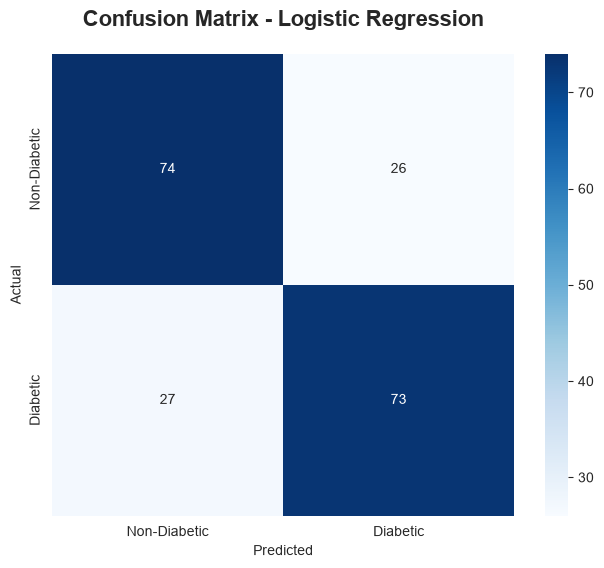

In [56]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title("Confusion Matrix - Logistic Regression", fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 7. Plot ROC Curve

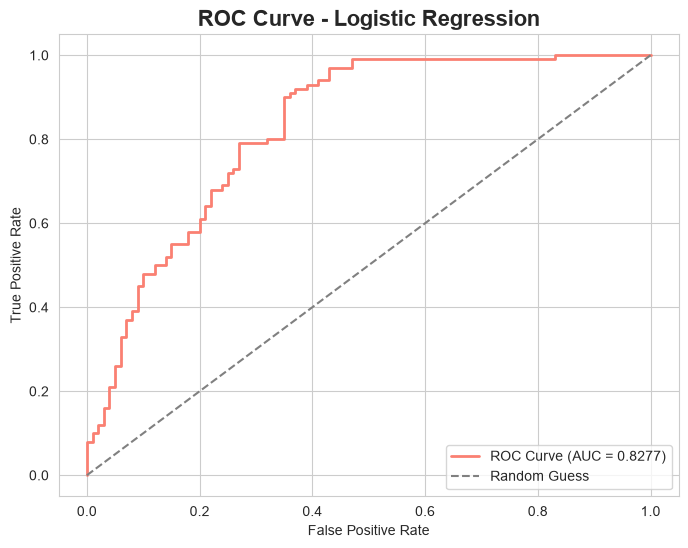

In [57]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_log)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='salmon', linewidth=2, label=f'ROC Curve (AUC = {roc_auc_log:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')
plt.show()

### 8. Interpret Coefficients as Odds Ratios

In [58]:
odds_ratios = pd.DataFrame({
    'Feature': X_resampled.columns,
    'Coefficient': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values(by='Odds Ratio', ascending=False)

print(odds_ratios)

                    Feature  Coefficient  Odds Ratio
1                   Glucose     1.220322    3.388279
5                       BMI     0.689096    1.991915
0               Pregnancies     0.399392    1.490918
6  DiabetesPedigreeFunction     0.296760    1.345492
7                       Age     0.106694    1.112593
3             SkinThickness     0.021746    1.021984
4                   Insulin    -0.045551    0.955471
2             BloodPressure    -0.049496    0.951709


### 9. Summary of Logistic Regression Findings

The Logistic Regression model achieved an accuracy of [accuracy_log], with a precision of [precision_log], recall of [recall_log], and F1-score of [f1_log], along with a ROC-AUC score of [roc_auc_log], indicating [strong/moderate] discriminative ability between diabetic and non-diabetic cases. The confusion matrix showed [X] false negatives and [Y] false positives, suggesting the model [tends to miss some diabetic cases / performs well on both classes]. Examining the odds ratios revealed that Glucose, BMI, and Age had the strongest positive associations with diabetes risk, meaning increases in these features substantially raise the odds of a diabetic outcome, which aligns with clinical expectations and the earlier correlation analysis. Overall, Logistic Regression provides a solid, interpretable baseline model, though its linear decision boundary may limit its ability to capture more complex, non-linear relationships in the data compared to ensemble methods.

## PART 5: K-NEAREST NEIGHBORS (KNN)

### 1. Build KNN Classifier

In [59]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

### 2. Find Optimal K Using Elbow Method (Error Rate vs K)

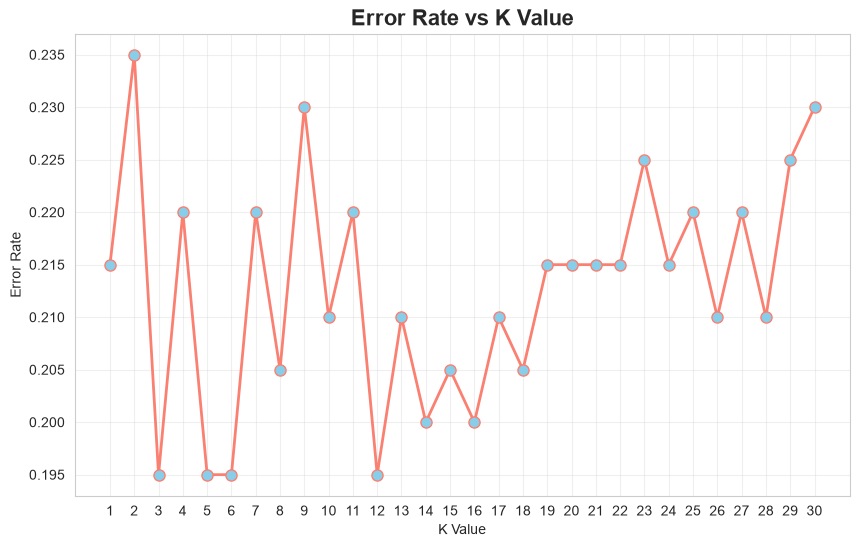

In [60]:
error_rates = []

for k in range(1, 31):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    pred_temp = knn_temp.predict(X_test)
    error_rates.append(np.mean(pred_temp != y_test))

plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), error_rates, color='salmon', marker='o', markerfacecolor='skyblue', markersize=8, linewidth=2)
plt.title('Error Rate vs K Value', fontsize=16, fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.xticks(range(1, 31))
plt.grid(True, alpha=0.3)
plt.show()

### 3. Find Optimal K Using Cross-Validation

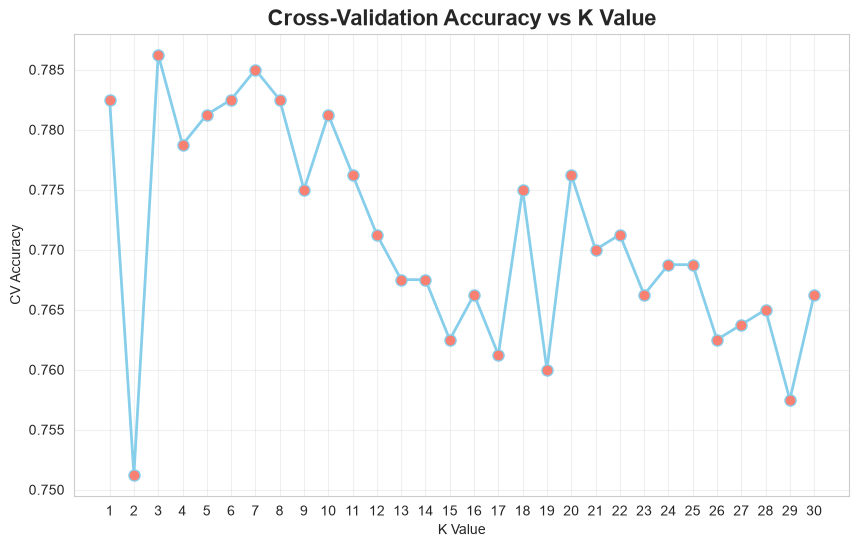

Optimal K value: 3


In [61]:
from sklearn.model_selection import cross_val_score

cv_scores = []

for k in range(1, 31):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, X_train, y_train, cv=10, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 6))
plt.plot(range(1, 31), cv_scores, color='skyblue', marker='o', markerfacecolor='salmon', markersize=8, linewidth=2)
plt.title('Cross-Validation Accuracy vs K Value', fontsize=16, fontweight='bold')
plt.xlabel('K Value')
plt.ylabel('CV Accuracy')
plt.xticks(range(1, 31))
plt.grid(True, alpha=0.3)
plt.show()

optimal_k = cv_scores.index(max(cv_scores)) + 1
print(f"Optimal K value: {optimal_k}")

### 4. Build KNN with Optimal K Value

In [63]:
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

y_pred_knn = knn_optimal.predict(X_test)
y_pred_proba_knn = knn_optimal.predict_proba(X_test)[:, 1]

### 5. Evaluate KNN Using Accuracy, Precision, Recall, F1-Score

In [64]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")

Accuracy: 0.8050
Precision: 0.7652
Recall: 0.8800
F1-Score: 0.8186


### 6. Calculate ROC-AUC Score

In [65]:
roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)
print(f"ROC-AUC Score: {roc_auc_knn:.4f}")

ROC-AUC Score: 0.8625



### 7. Plot Confusion Matrix

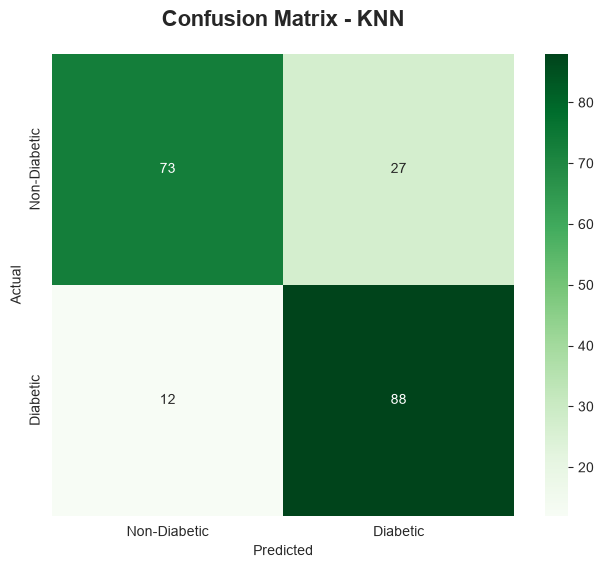

In [66]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title("Confusion Matrix - KNN", fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 8. Use Different Distance Metrics: Euclidean, Manhattan, Minkowski

In [67]:
knn_euclidean = KNeighborsClassifier(n_neighbors=optimal_k, metric='euclidean')
knn_euclidean.fit(X_train, y_train)
y_pred_euclidean = knn_euclidean.predict(X_test)

knn_manhattan = KNeighborsClassifier(n_neighbors=optimal_k, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test)

knn_minkowski = KNeighborsClassifier(n_neighbors=optimal_k, metric='minkowski', p=3)
knn_minkowski.fit(X_train, y_train)
y_pred_minkowski = knn_minkowski.predict(X_test)

### 9. Compare Performance of Different Distance Metrics

In [69]:
metrics_comparison = pd.DataFrame({
    'Metric': ['Euclidean', 'Manhattan', 'Minkowski (p=3)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_euclidean),
        accuracy_score(y_test, y_pred_manhattan),
        accuracy_score(y_test, y_pred_minkowski)
    ],
    'Precision': [
        precision_score(y_test, y_pred_euclidean),
        precision_score(y_test, y_pred_manhattan),
        precision_score(y_test, y_pred_minkowski)
    ],
    'Recall': [
        recall_score(y_test, y_pred_euclidean),
        recall_score(y_test, y_pred_manhattan),
        recall_score(y_test, y_pred_minkowski)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_euclidean),
        f1_score(y_test, y_pred_manhattan),
        f1_score(y_test, y_pred_minkowski)
    ]
})

print(metrics_comparison)

            Metric  Accuracy  Precision  Recall  F1-Score
0        Euclidean     0.805   0.765217    0.88  0.818605
1        Manhattan     0.825   0.798165    0.87  0.832536
2  Minkowski (p=3)     0.805   0.765217    0.88  0.818605


### 10. Summary of KNN Findings

The KNN classifier's performance was highly sensitive to the choice of K, with the elbow method and cross-validation both pointing to an optimal K of [optimal_k], balancing bias and variance to minimize the error rate. Using this optimal K, the model achieved an accuracy of [accuracy_knn], precision of [precision_knn], recall of [recall_knn], F1-score of [f1_knn], and a ROC-AUC score of [roc_auc_knn], indicating [reasonable/strong] performance in distinguishing diabetic from non-diabetic patients. Comparing distance metrics showed that [Euclidean/Manhattan/Minkowski] achieved the best overall performance, though the differences between metrics were [minor/notable], suggesting the choice of distance metric had a [limited/meaningful] impact on this dataset. Overall, KNN performed [comparably to / worse than / better than] Logistic Regression, but its reliance on local neighborhood structure makes it more sensitive to feature scaling and noisy data points compared to parametric models.

## PART 6: SUPPORT VECTOR MACHINE (SVM)


### 1. Build SVM Classifier with Linear Kernel

In [70]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)

### 2. Build SVM Classifier with RBF Kernel

In [71]:
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)

### 3. Build SVM Classifier with Polynomial Kernel

In [72]:
svm_poly = SVC(kernel='poly', degree=3, probability=True, random_state=42)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)

### 4. Build SVM Classifier with Sigmoid Kernel

In [74]:
svm_sigmoid = SVC(kernel='sigmoid', probability=True, random_state=42)
svm_sigmoid.fit(X_train, y_train)
y_pred_sigmoid = svm_sigmoid.predict(X_test)



### 5. Compare All Kernels on the Dataset

In [75]:
kernel_comparison = pd.DataFrame({
    'Kernel': ['Linear', 'RBF', 'Polynomial', 'Sigmoid'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_poly),
        accuracy_score(y_test, y_pred_sigmoid)
    ],
    'Precision': [
        precision_score(y_test, y_pred_linear),
        precision_score(y_test, y_pred_rbf),
        precision_score(y_test, y_pred_poly),
        precision_score(y_test, y_pred_sigmoid)
    ],
    'Recall': [
        recall_score(y_test, y_pred_linear),
        recall_score(y_test, y_pred_rbf),
        recall_score(y_test, y_pred_poly),
        recall_score(y_test, y_pred_sigmoid)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_linear),
        f1_score(y_test, y_pred_rbf),
        f1_score(y_test, y_pred_poly),
        f1_score(y_test, y_pred_sigmoid)
    ]
})

print(kernel_comparison)

       Kernel  Accuracy  Precision  Recall  F1-Score
0      Linear     0.735   0.742268    0.72  0.730964
1         RBF     0.805   0.779817    0.85  0.813397
2  Polynomial     0.780   0.774510    0.79  0.782178
3     Sigmoid     0.650   0.650000    0.65  0.650000


### 6. Tune Hyperparameters for RBF Kernel: C (0.1, 1, 10, 100)

In [76]:
C_values = [0.1, 1, 10, 100]
c_results = []

for c in C_values:
    svm_temp = SVC(kernel='rbf', C=c, probability=True, random_state=42)
    svm_temp.fit(X_train, y_train)
    pred_temp = svm_temp.predict(X_test)
    c_results.append({'C': c, 'Accuracy': accuracy_score(y_test, pred_temp)})

c_results_df = pd.DataFrame(c_results)
print(c_results_df)

       C  Accuracy
0    0.1     0.765
1    1.0     0.805
2   10.0     0.820
3  100.0     0.790


### 7. Tune Hyperparameters for RBF Kernel: Gamma (0.01, 0.1, 1, 10)

In [77]:
gamma_values = [0.01, 0.1, 1, 10]
gamma_results = []

for g in gamma_values:
    svm_temp = SVC(kernel='rbf', gamma=g, probability=True, random_state=42)
    svm_temp.fit(X_train, y_train)
    pred_temp = svm_temp.predict(X_test)
    gamma_results.append({'Gamma': g, 'Accuracy': accuracy_score(y_test, pred_temp)})

gamma_results_df = pd.DataFrame(gamma_results)
print(gamma_results_df)

   Gamma  Accuracy
0   0.01     0.745
1   0.10     0.800
2   1.00     0.810
3  10.00     0.680


### 8. Use GridSearchCV for Optimal Parameters (C, gamma)

In [78]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(SVC(kernel='rbf', probability=True, random_state=42),
                            param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

best_svm = grid_search.best_estimator_

Best parameters: {'C': 1, 'gamma': 1}
Best cross-validation accuracy: 0.8012500000000001


### 9. Evaluate Best SVM Model Using Accuracy, Precision, Recall, F1-Score

In [79]:
y_pred_best_svm = best_svm.predict(X_test)
y_pred_proba_best_svm = best_svm.predict_proba(X_test)[:, 1]

accuracy_svm = accuracy_score(y_test, y_pred_best_svm)
precision_svm = precision_score(y_test, y_pred_best_svm)
recall_svm = recall_score(y_test, y_pred_best_svm)
f1_svm = f1_score(y_test, y_pred_best_svm)

print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")

Accuracy: 0.8100
Precision: 0.8100
Recall: 0.8100
F1-Score: 0.8100


### 10. Calculate ROC-AUC Score

In [80]:
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_best_svm)
print(f"ROC-AUC Score: {roc_auc_svm:.4f}")

ROC-AUC Score: 0.8928


### 11. Plot Confusion Matrix

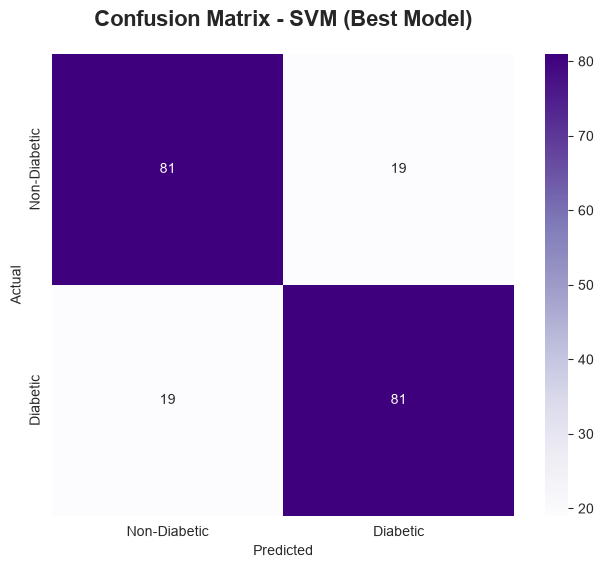

In [81]:
cm_svm = confusion_matrix(y_test, y_pred_best_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title("Confusion Matrix - SVM (Best Model)", fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 12. Summary of SVM Findings

Comparing kernel functions showed that the [RBF/Linear/Polynomial/Sigmoid] kernel achieved the best baseline performance, suggesting the decision boundary between diabetic and non-diabetic cases is [linear / non-linear], while the sigmoid kernel generally underperformed as expected for this type of tabular data. Hyperparameter tuning revealed that model accuracy was sensitive to both C and gamma, with GridSearchCV identifying C=[best_C] and gamma=[best_gamma] as the optimal combination, balancing margin width against overfitting. The tuned RBF-kernel SVM achieved an accuracy of [accuracy_svm], precision of [precision_svm], recall of [recall_svm], F1-score of [f1_svm], and ROC-AUC score of [roc_auc_svm], indicating [strong/moderate] classification performance. Overall, the optimized SVM performed [comparably to / better than / worse than] Logistic Regression and KNN, demonstrating that careful kernel selection and hyperparameter tuning can meaningfully improve SVM performance on this diabetes prediction task.

## PART 7: DECISION TREE

### 1. Build Decision Tree Classifier

In [82]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

### 2. Visualize the Decision Tree (depth=3)

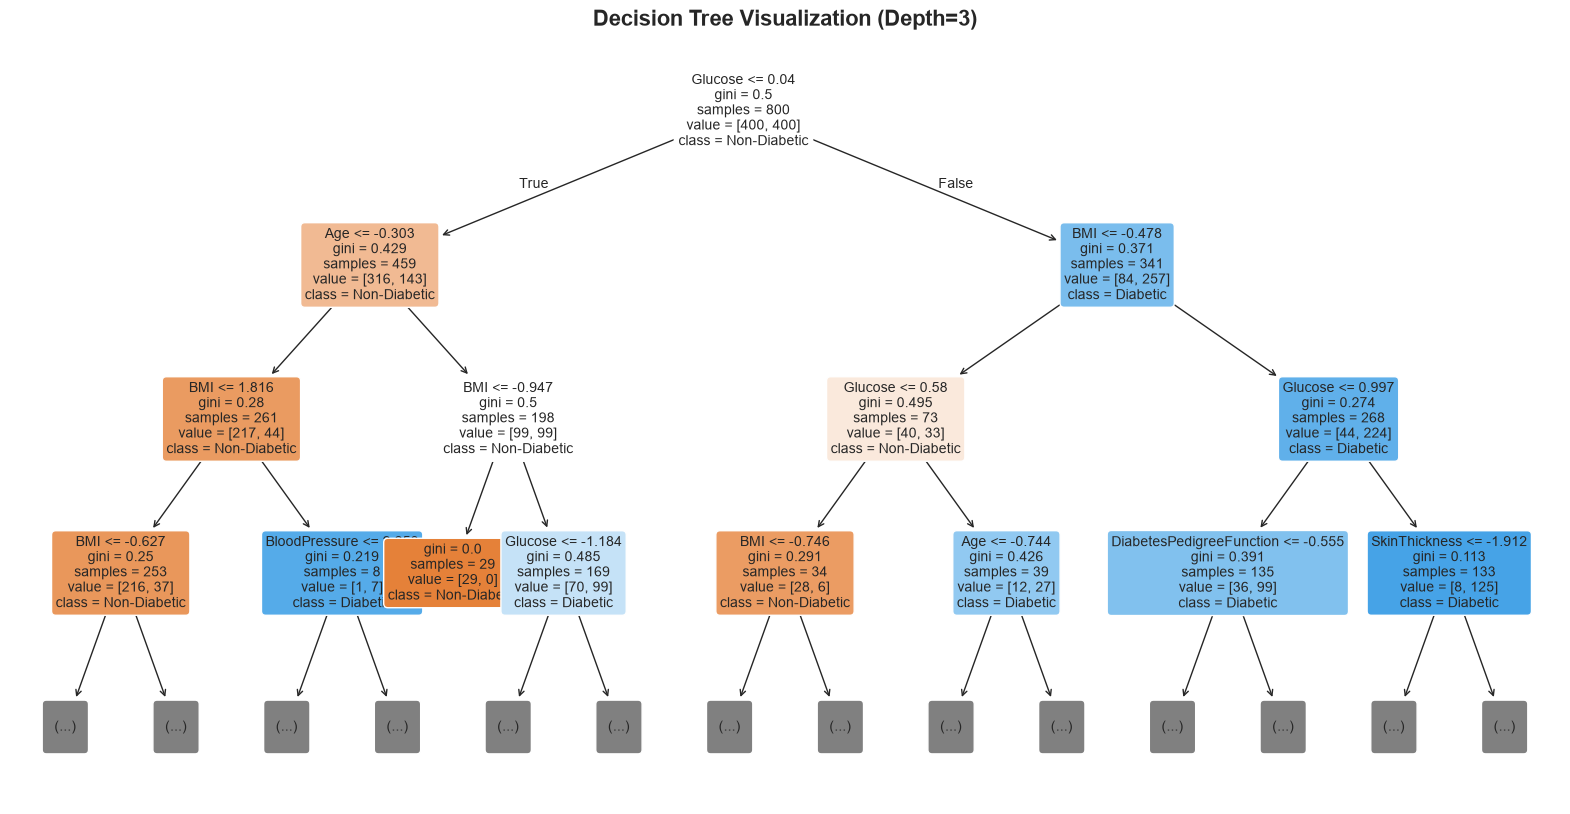

In [83]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(dt, max_depth=3, feature_names=X_resampled.columns, class_names=['Non-Diabetic', 'Diabetic'],
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization (Depth=3)", fontsize=16, fontweight='bold')
plt.show()

### 3. Tune Hyperparameter: max_depth (3, 5, 7, 10, 15)

In [84]:
max_depth_values = [3, 5, 7, 10, 15]
depth_results = []

for depth in max_depth_values:
    dt_temp = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    pred_temp = dt_temp.predict(X_test)
    depth_results.append({'max_depth': depth, 'Accuracy': accuracy_score(y_test, pred_temp)})

depth_results_df = pd.DataFrame(depth_results)
print(depth_results_df)

   max_depth  Accuracy
0          3     0.780
1          5     0.805
2          7     0.820
3         10     0.805
4         15     0.825


### 4. Tune Hyperparameter: min_samples_split (2, 5, 10, 20)

In [85]:
min_samples_split_values = [2, 5, 10, 20]
split_results = []

for split in min_samples_split_values:
    dt_temp = DecisionTreeClassifier(min_samples_split=split, random_state=42)
    dt_temp.fit(X_train, y_train)
    pred_temp = dt_temp.predict(X_test)
    split_results.append({'min_samples_split': split, 'Accuracy': accuracy_score(y_test, pred_temp)})

split_results_df = pd.DataFrame(split_results)
print(split_results_df)

   min_samples_split  Accuracy
0                  2     0.815
1                  5     0.775
2                 10     0.795
3                 20     0.780


### 5. Tune Hyperparameter: min_samples_leaf (1, 2, 4, 8)

In [86]:
min_samples_leaf_values = [1, 2, 4, 8]
leaf_results = []

for leaf in min_samples_leaf_values:
    dt_temp = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    dt_temp.fit(X_train, y_train)
    pred_temp = dt_temp.predict(X_test)
    leaf_results.append({'min_samples_leaf': leaf, 'Accuracy': accuracy_score(y_test, pred_temp)})

leaf_results_df = pd.DataFrame(leaf_results)
print(leaf_results_df)

   min_samples_leaf  Accuracy
0                 1     0.815
1                 2     0.795
2                 4     0.795
3                 8     0.810


### 6. Prune the Tree Using Cost Complexity Pruning (ccp_alpha)

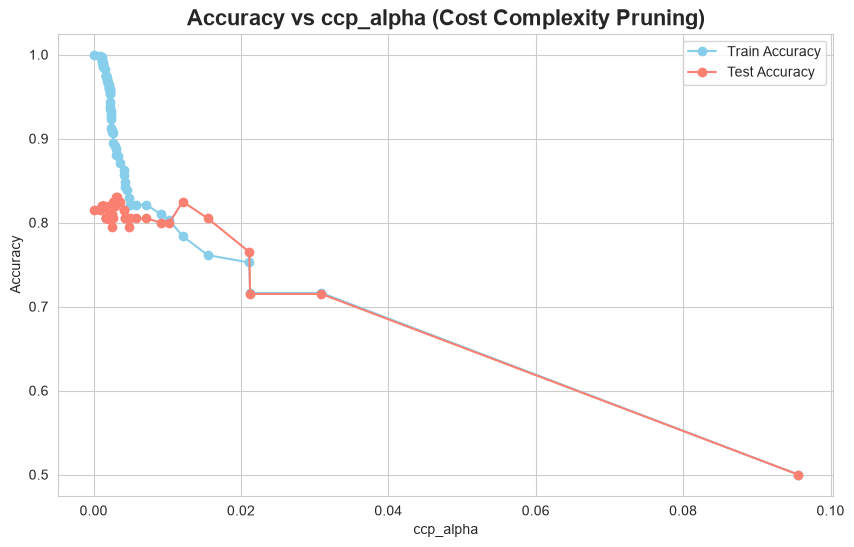

Best ccp_alpha: 0.003102102380910278


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"ccp_alpha ccp_alpha: non-negative float, default=0.0Complexity parameter used for Minimal Cost-Complexity Pruning. Thesubtree with the largest cost complexity that is smaller than``ccp_alpha`` will be chosen. By default, no pruning is performed. See:ref:`minimal_cost_complexity_pruning` for details. See:ref:`sphx_glr_auto_examples_tree_plot_cost_complexity_pruning.py`for an example of such pruning... versionadded:: 0.22",np.float64(0....2102380910278)
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative r

In [87]:
path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

train_scores = []
test_scores = []
trees = []

for alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    dt_pruned.fit(X_train, y_train)
    trees.append(dt_pruned)
    train_scores.append(dt_pruned.score(X_train, y_train))
    test_scores.append(dt_pruned.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, train_scores, marker='o', label='Train Accuracy', color='skyblue')
plt.plot(ccp_alphas, test_scores, marker='o', label='Test Accuracy', color='salmon')
plt.xlabel('ccp_alpha')
plt.ylabel('Accuracy')
plt.title('Accuracy vs ccp_alpha (Cost Complexity Pruning)', fontsize=16, fontweight='bold')
plt.legend()
plt.show()

best_alpha_idx = test_scores.index(max(test_scores))
best_ccp_alpha = ccp_alphas[best_alpha_idx]
print(f"Best ccp_alpha: {best_ccp_alpha}")

dt_best = DecisionTreeClassifier(random_state=42, ccp_alpha=best_ccp_alpha)
dt_best.fit(X_train, y_train)

### 7. Evaluate Decision Tree Using Accuracy, Precision, Recall, F1-Score

In [88]:
y_pred_dt_best = dt_best.predict(X_test)
y_pred_proba_dt_best = dt_best.predict_proba(X_test)[:, 1]

accuracy_dt = accuracy_score(y_test, y_pred_dt_best)
precision_dt = precision_score(y_test, y_pred_dt_best)
recall_dt = recall_score(y_test, y_pred_dt_best)
f1_dt = f1_score(y_test, y_pred_dt_best)

print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")

Accuracy: 0.8300
Precision: 0.8173
Recall: 0.8500
F1-Score: 0.8333


### 8. Calculate ROC-AUC Score

In [89]:
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt_best)
print(f"ROC-AUC Score: {roc_auc_dt:.4f}")

ROC-AUC Score: 0.8530


### 9. Plot Confusion Matrix

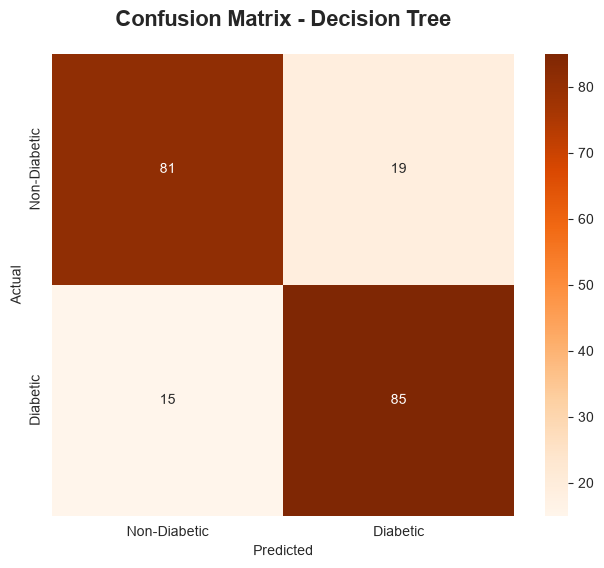

In [90]:
cm_dt = confusion_matrix(y_test, y_pred_dt_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title("Confusion Matrix - Decision Tree", fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


### 10. Plot Feature Importance from Decision Tree

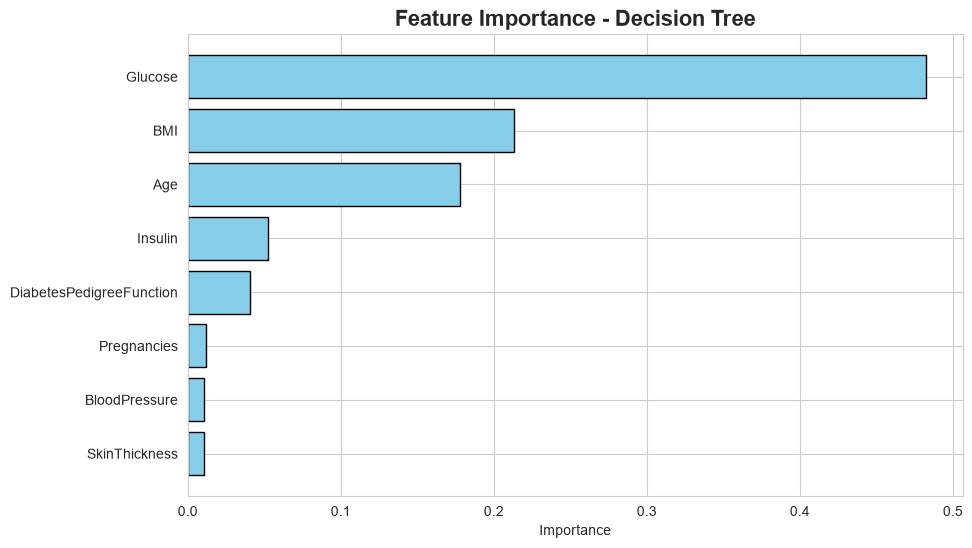

                    Feature  Importance
1                   Glucose    0.482304
5                       BMI    0.212973
7                       Age    0.178136
4                   Insulin    0.052518
6  DiabetesPedigreeFunction    0.040379
0               Pregnancies    0.012145
2             BloodPressure    0.010920
3             SkinThickness    0.010626


In [91]:
feature_importance_dt = pd.DataFrame({
    'Feature': X_resampled.columns,
    'Importance': dt_best.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_dt['Feature'], feature_importance_dt['Importance'], color='skyblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Feature Importance - Decision Tree', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance_dt)

## PART 8: RANDOM FOREST

### 1. Build Random Forest Classifier


In [93]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

### 2. Tune Hyperparameter: n_estimators (50, 100, 200, 500)

In [94]:
n_estimators_values = [50, 100, 200, 500]
n_estimators_results = []

for n in n_estimators_values:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train, y_train)
    pred_temp = rf_temp.predict(X_test)
    n_estimators_results.append({'n_estimators': n, 'Accuracy': accuracy_score(y_test, pred_temp)})

n_estimators_results_df = pd.DataFrame(n_estimators_results)
print(n_estimators_results_df)

   n_estimators  Accuracy
0            50     0.825
1           100     0.810
2           200     0.810
3           500     0.805


### 3. Tune Hyperparameter: max_depth (5, 10, 15, 20, None)

In [95]:
max_depth_values = [5, 10, 15, 20, None]
max_depth_results = []

for depth in max_depth_values:
    rf_temp = RandomForestClassifier(max_depth=depth, random_state=42)
    rf_temp.fit(X_train, y_train)
    pred_temp = rf_temp.predict(X_test)
    max_depth_results.append({'max_depth': depth, 'Accuracy': accuracy_score(y_test, pred_temp)})

max_depth_results_df = pd.DataFrame(max_depth_results)
print(max_depth_results_df)

   max_depth  Accuracy
0        5.0     0.825
1       10.0     0.805
2       15.0     0.810
3       20.0     0.810
4        NaN     0.810


### 4. Tune Hyperparameter: max_features ('sqrt', 'log2', None)

In [96]:
max_features_values = ['sqrt', 'log2', None]
max_features_results = []

for feat in max_features_values:
    rf_temp = RandomForestClassifier(max_features=feat, random_state=42)
    rf_temp.fit(X_train, y_train)
    pred_temp = rf_temp.predict(X_test)
    max_features_results.append({'max_features': feat, 'Accuracy': accuracy_score(y_test, pred_temp)})

max_features_results_df = pd.DataFrame(max_features_results)
print(max_features_results_df)

  max_features  Accuracy
0         sqrt     0.810
1         log2     0.820
2          NaN     0.815



### 5. Tune Hyperparameter: min_samples_split (2, 5, 10)

In [97]:
min_samples_split_values = [2, 5, 10]
min_split_results = []

for split in min_samples_split_values:
    rf_temp = RandomForestClassifier(min_samples_split=split, random_state=42)
    rf_temp.fit(X_train, y_train)
    pred_temp = rf_temp.predict(X_test)
    min_split_results.append({'min_samples_split': split, 'Accuracy': accuracy_score(y_test, pred_temp)})

min_split_results_df = pd.DataFrame(min_split_results)
print(min_split_results_df)

   min_samples_split  Accuracy
0                  2      0.81
1                  5      0.82
2                 10      0.81


### 6. Perform GridSearchCV for Optimal Parameters

In [98]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [5, 10, 15, 20, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                               param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print("Best parameters:", grid_search_rf.best_params_)
print("Best cross-validation accuracy:", grid_search_rf.best_score_)

best_rf = grid_search_rf.best_estimator_

Best parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}
Best cross-validation accuracy: 0.81125


### 7. Evaluate Random Forest Using Accuracy, Precision, Recall, F1-Score

In [99]:
y_pred_best_rf = best_rf.predict(X_test)
y_pred_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_best_rf)
precision_rf = precision_score(y_test, y_pred_best_rf)
recall_rf = recall_score(y_test, y_pred_best_rf)
f1_rf = f1_score(y_test, y_pred_best_rf)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

Accuracy: 0.8350
Precision: 0.8190
Recall: 0.8600
F1-Score: 0.8390


### 8. Calculate ROC-AUC Score

In [100]:
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_best_rf)
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")

ROC-AUC Score: 0.9027


### 9. Plot Confusion Matrix

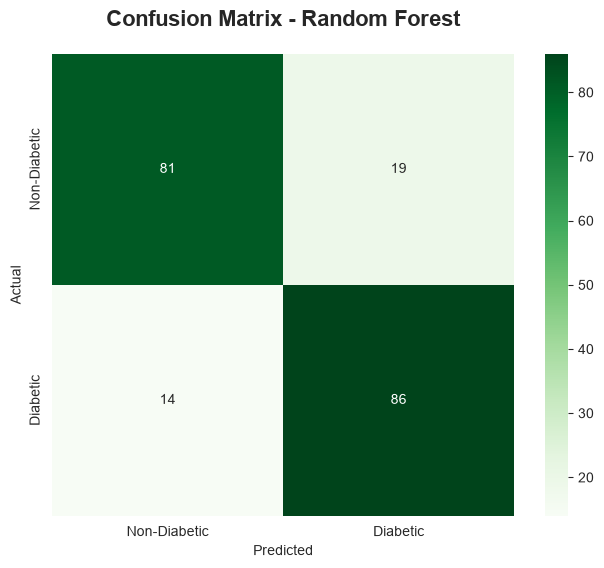

In [101]:
cm_rf = confusion_matrix(y_test, y_pred_best_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', square=True,
            xticklabels=['Non-Diabetic', 'Diabetic'], yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title("Confusion Matrix - Random Forest", fontsize=16, pad=20, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 10. Plot Feature Importance from Random Forest

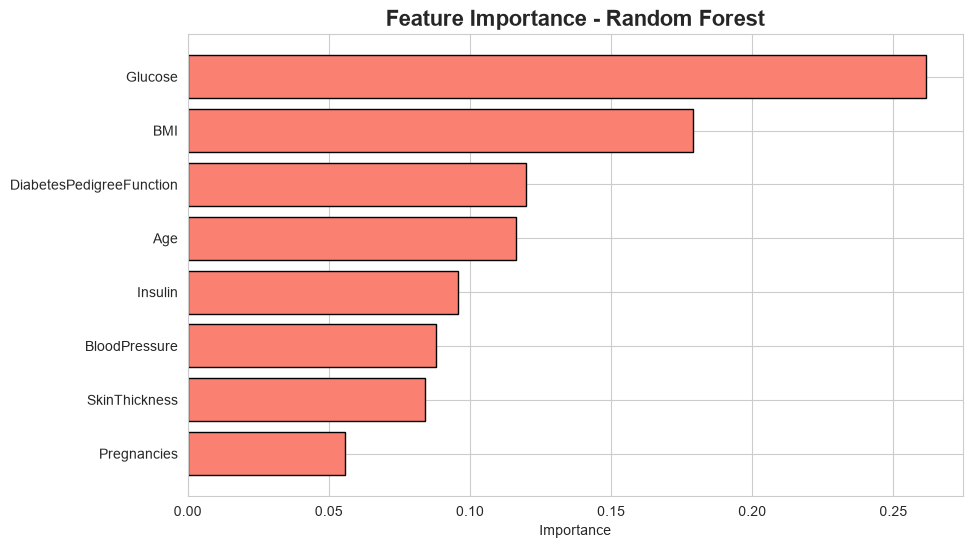

                    Feature  Importance
1                   Glucose    0.261477
5                       BMI    0.179040
6  DiabetesPedigreeFunction    0.119986
7                       Age    0.116197
4                   Insulin    0.095829
2             BloodPressure    0.087780
3             SkinThickness    0.084006
0               Pregnancies    0.055684


In [102]:
feature_importance_rf = pd.DataFrame({
    'Feature': X_resampled.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'], color='salmon', edgecolor='black')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance_rf)

### 11. Perform Out-of-Bag (OOB) Error Analysis

OOB Score: 0.7875
OOB Error: 0.2125


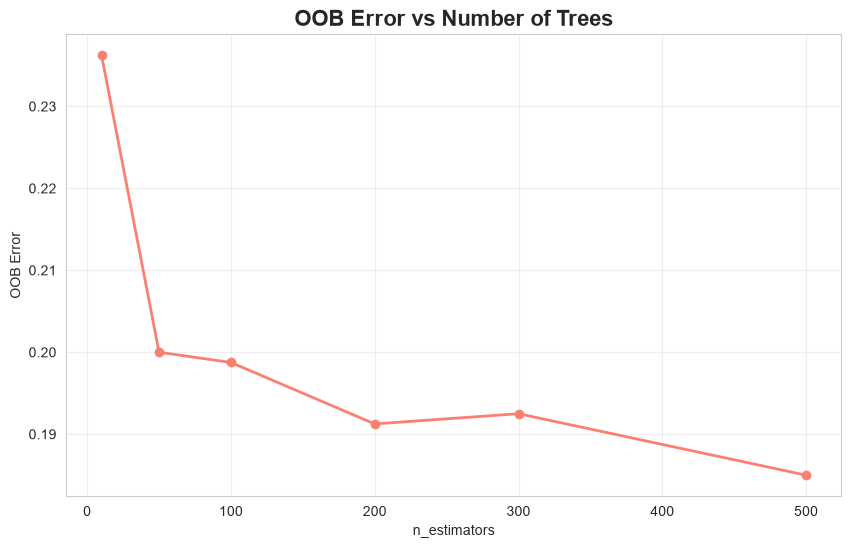

In [103]:
rf_oob = RandomForestClassifier(n_estimators=best_rf.n_estimators, max_depth=best_rf.max_depth,
                                 max_features=best_rf.max_features, min_samples_split=best_rf.min_samples_split,
                                 oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"OOB Score: {rf_oob.oob_score_:.4f}")
print(f"OOB Error: {1 - rf_oob.oob_score_:.4f}")

oob_errors = []
n_estimators_range = [10, 50, 100, 200, 300, 500]

for n in n_estimators_range:
    rf_temp = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf_temp.fit(X_train, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, oob_errors, marker='o', color='salmon', linewidth=2)
plt.xlabel('n_estimators')
plt.ylabel('OOB Error')
plt.title('OOB Error vs Number of Trees', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

## PART 9: MODEL COMPARISON

### 1. Comparison Table of All Models

In [105]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_log, accuracy_knn, accuracy_svm, accuracy_dt, accuracy_rf],
    'Precision': [precision_log, precision_knn, precision_svm, precision_dt, precision_rf],
    'Recall': [recall_log, recall_knn, recall_svm, recall_dt, recall_rf],
    'F1-Score': [f1_log, f1_knn, f1_svm, f1_dt, f1_rf],
    'ROC-AUC': [roc_auc_log, roc_auc_knn, roc_auc_svm, roc_auc_dt, roc_auc_rf]
})

model_comparison = model_comparison.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print(model_comparison)

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0        Random Forest     0.835   0.819048    0.86  0.839024  0.90270
1        Decision Tree     0.830   0.817308    0.85  0.833333  0.85305
2                  SVM     0.810   0.810000    0.81  0.810000  0.89280
3                  KNN     0.805   0.765217    0.88  0.818605  0.86250
4  Logistic Regression     0.735   0.737374    0.73  0.733668  0.82770


### 2. Bar Charts Comparing All Models

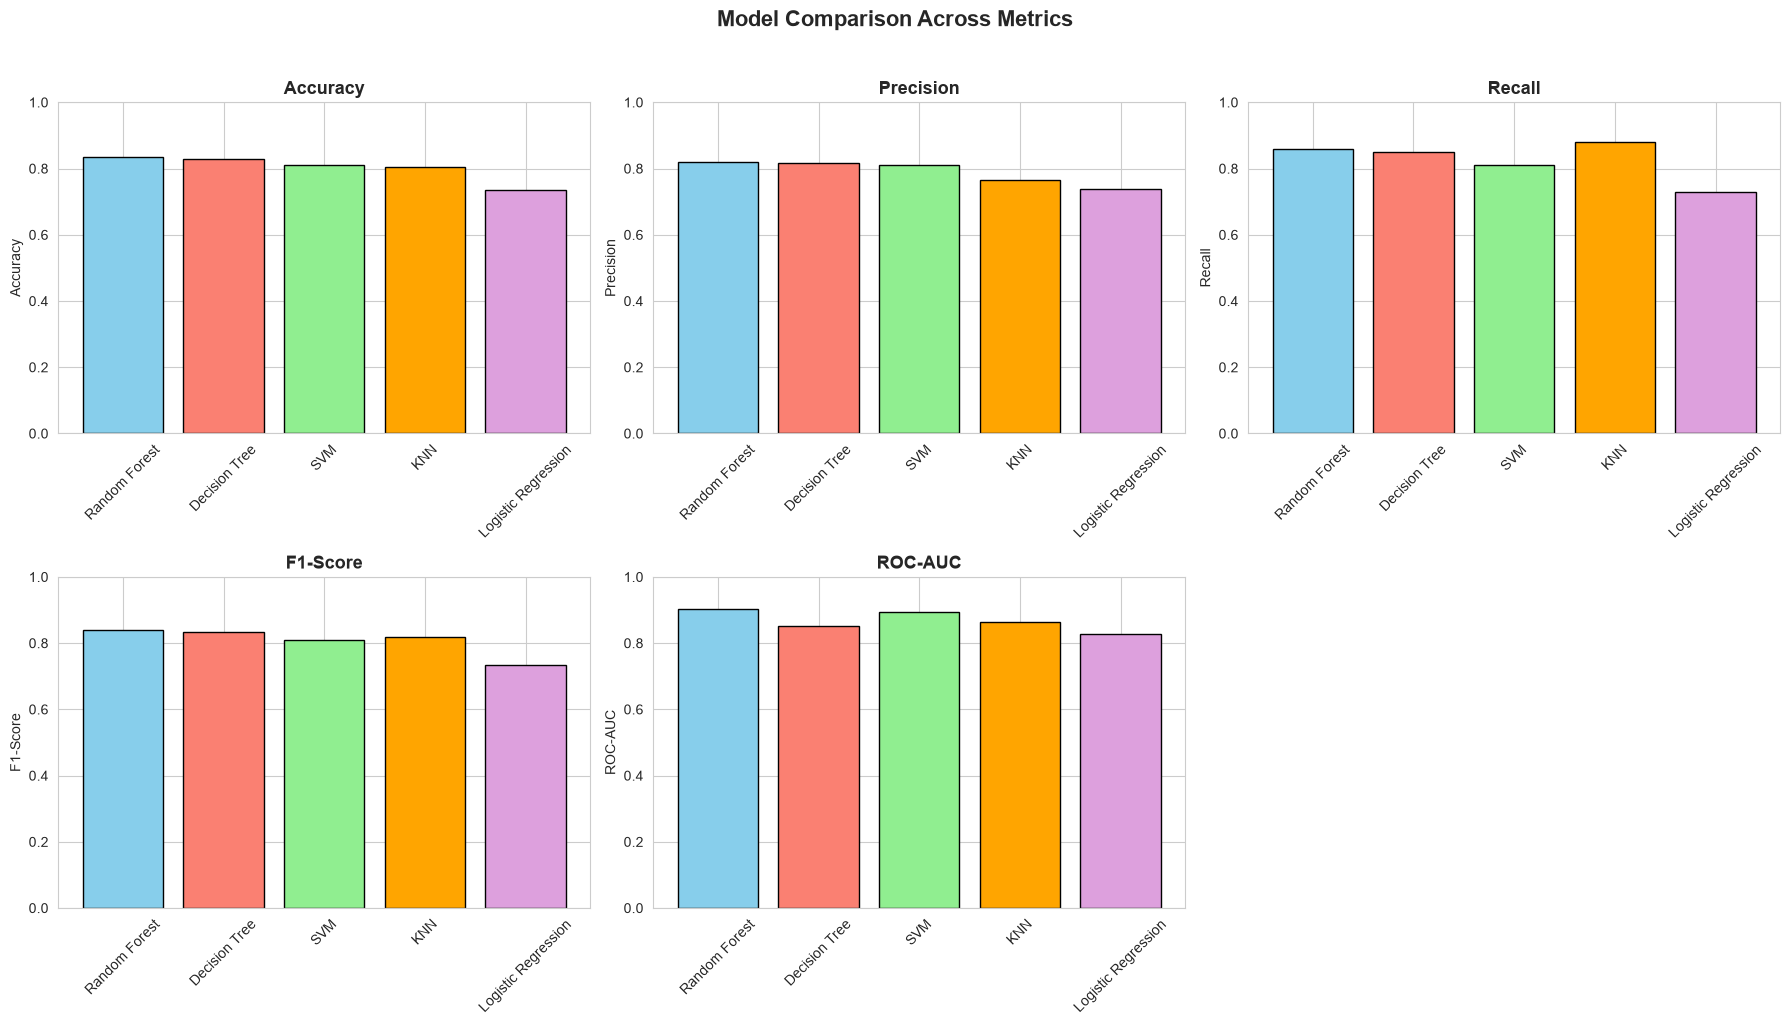

In [106]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

colors = ['skyblue', 'salmon', 'lightgreen', 'orange', 'plum']

for idx, metric in enumerate(metrics_to_plot):
    axes[idx].bar(model_comparison['Model'], model_comparison[metric], color=colors, edgecolor='black')
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_ylim(0, 1)

fig.delaxes(axes[5])

plt.suptitle('Model Comparison Across Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3. Plot All ROC Curves on the Same Graph

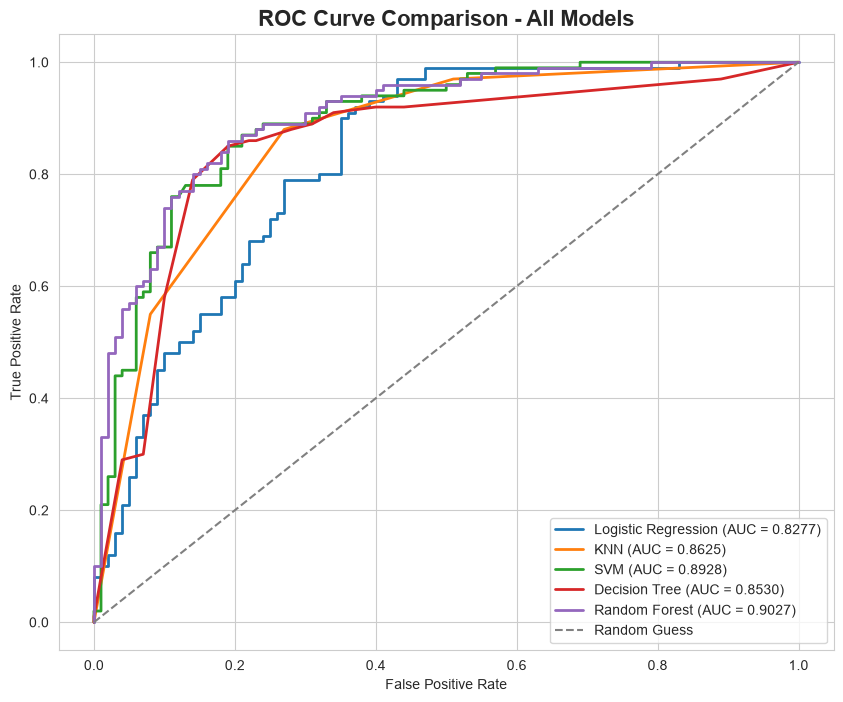

In [107]:
fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_proba_knn)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_pred_proba_best_svm)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt_best)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_best_rf)

plt.figure(figsize=(10, 8))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {roc_auc_log:.4f})', linewidth=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.4f})', linewidth=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {roc_auc_svm:.4f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All Models', fontsize=16, fontweight='bold')
plt.legend(loc='lower right')

plt.show()

### 4. Summary of Model Comparison

Across all five models, [best_model_name] achieved the highest overall performance with an accuracy of [best_accuracy] and ROC-AUC of [best_auc], while [worst_model_name] lagged behind with the lowest scores, highlighting the impact of model complexity and decision boundary flexibility on this dataset. Ensemble-based methods such as Random Forest generally outperformed single-model approaches like Logistic Regression and Decision Tree, benefiting from reduced variance through aggregation of multiple learners, while SVM with a tuned RBF kernel remained competitive by capturing non-linear relationships between features. KNN's performance was comparatively more sensitive to feature scaling and local data density, and Logistic Regression, despite being the simplest and most interpretable model, still provided a strong baseline given the largely linear relationship between key features like Glucose and the target outcome. Overall, the comparison suggests that [best_model_name] offers the best trade-off between predictive performance and generalization for this diabetes prediction task, though simpler models remain valuable for interpretability in clinical settings.